Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded — Train: 33641 | Val: 4205 | Test: 4206
Vocab Size: 1401
--> Found existing checkpoint! Resuming training from Epoch 16/15

--> Loaded best model weights for final evaluation.

             TEST EVALUATION            
Test Loss:      0.0778
Test Accuracy:  0.9693
Test Precision: 0.9674
Test Recall:    0.9691
Test F1-Score:  0.9682


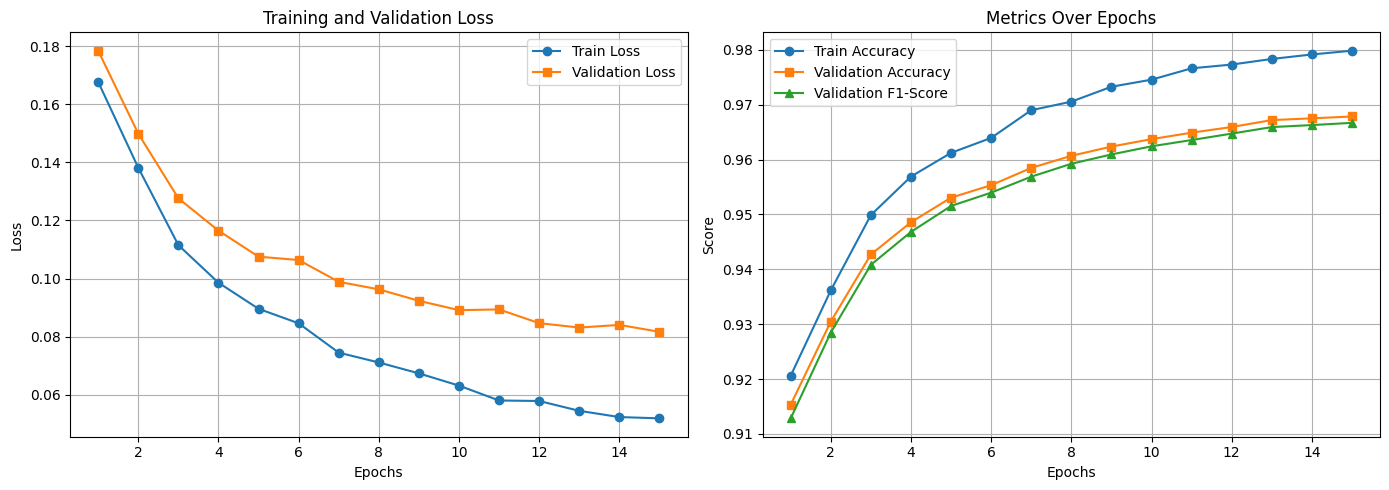

Model and tokenizer files successfully saved to: /content/drive/MyDrive/final_seg_model


In [21]:
# ==============================================================================
# 0. INSTALL DEPENDENCIES & LIBRARIES
# ==============================================================================
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np
from google.colab import drive

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==============================================================================
# 1. MOUNT GOOGLE DRIVE & SET FILE PATHS
# Update these paths to match your exact file locations in Drive!
# ==============================================================================
drive.mount('/content/drive')

train_path = "/content/drive/MyDrive/train.jsonl"
val_path   = "/content/drive/MyDrive/validation.jsonl"
test_path  = "/content/drive/MyDrive/test.jsonl"

def load_jsonl(filepath):
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_data = load_jsonl(train_path)
val_data   = load_jsonl(val_path)
test_data  = load_jsonl(test_path)

print(f"Loaded — Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==============================================================================
# 2. VOCABULARY AND LABEL MAP BUILDER
# ==============================================================================
LABEL_MAP = {"<PAD>": 0, "B": 1, "I": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def build_vocab(datasets):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for dataset in datasets:
        for item in dataset:
            for unit in item['seg_units']:
                if unit not in vocab:
                    vocab[unit] = len(vocab)
    return vocab

# Build vocab across all splits to ensure all tokens are indexed
vocab = build_vocab([train_data, val_data, test_data])
print(f"Vocab Size: {len(vocab)}")

# ==============================================================================
# 3. DATASET & DATALOADER DEFINITION
# ==============================================================================
class SegmentationDataset(Dataset):
    def __init__(self, data_list, vocab, label_map, max_len=128):
        self.data = []
        for item in data_list:
            units = [vocab.get(u, vocab["<UNK>"]) for u in item['seg_units']]
            labels = [label_map[l] for l in item['seg_labels']]

            # Truncate sequence if longer than max_len
            units = units[:max_len]
            labels = labels[:max_len]

            self.data.append((units, labels))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def pad_collate_fn(batch):
    units_list, labels_list = zip(*batch)
    max_len = max(len(u) for u in units_list)

    padded_units, padded_labels = [], []
    for u, l in zip(units_list, labels_list):
        pad_len = max_len - len(u)
        padded_units.append(u + [0] * pad_len)
        padded_labels.append(l + [0] * pad_len)

    return torch.tensor(padded_units, dtype=torch.long), torch.tensor(padded_labels, dtype=torch.long)

train_dataset = SegmentationDataset(train_data, vocab, LABEL_MAP)
val_dataset   = SegmentationDataset(val_data, vocab, LABEL_MAP)
test_dataset  = SegmentationDataset(test_data, vocab, LABEL_MAP)

# Set batch_size according to your dataset size (e.g., 8, 16, 32)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=pad_collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=pad_collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=pad_collate_fn)

# ==============================================================================
# 4. NEURAL NETWORK ARCHITECTURE
# ==============================================================================
class TransformerSegmenter(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=128, nhead=4, num_layers=2, max_len=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(x.size(0), -1)

        out = self.embedding(x) + self.pos_embedding(positions)
        padding_mask = (x == 0)

        out = self.transformer(out, src_key_padding_mask=padding_mask)
        logits = self.classifier(out)
        return logits

# ==============================================================================
# 5. TRAINING & EVALUATION SETUP
# ==============================================================================
model = TransformerSegmenter(len(vocab), num_classes=len(LABEL_MAP)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)

            loss = criterion(logits.view(-1, logits.shape[-1]), y.view(-1))
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            mask = (y != 0)  # Ignore PAD tokens in metrics

            all_preds.extend(preds[mask].cpu().numpy())
            all_targets.extend(y[mask].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    return avg_loss, acc, precision, recall, f1

# ==============================================================================
# 6. TRAINING LOOP WITH AUTOMATIC CHECKPOINT RESUME
# ==============================================================================
checkpoint_dir = "/content/drive/MyDrive/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
latest_checkpoint_path = os.path.join(checkpoint_dir, "latest_checkpoint.pt")
best_checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")

epochs = 15
start_epoch = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_loss = float('inf')

# Auto-resume training state if a saved checkpoint exists on Drive
if os.path.exists(latest_checkpoint_path):
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    history = checkpoint['history']
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    print(f"--> Found existing checkpoint! Resuming training from Epoch {start_epoch + 1}/{epochs}")
else:
    print("--> No checkpoint found. Starting fresh training...")

for epoch in range(start_epoch, epochs):
    model.train()
    total_train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits.view(-1, logits.shape[-1]), y.view(-1))

        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    train_loss, train_acc, _, _, _ = evaluate(model, train_loader, criterion)
    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # Checkpoint Payload
    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'vocab': vocab,
        'history': history,
        'best_val_loss': min(best_val_loss, val_loss)
    }

    # Always update the latest checkpoint for resuming interrupted runs
    torch.save(checkpoint_state, latest_checkpoint_path)

    # Save best model separately when validation loss improves
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(checkpoint_state, best_checkpoint_path)
        print(f"    [Checkpoint] Saved new best model (Val Loss: {val_loss:.4f})")

# Load the best weights before running test evaluation
if os.path.exists(best_checkpoint_path):
    best_checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print("\n--> Loaded best model weights for final evaluation.")

# ==============================================================================
# 7. FINAL TEST EVALUATION
# ==============================================================================
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(model, test_loader, criterion)

print("\n" + "="*40)
print("             TEST EVALUATION            ")
print("="*40)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print("="*40)

# ==============================================================================
# 8. VISUALIZATION & PLOTTING
# ==============================================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['train_acc']) + 1), history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label='Validation Accuracy', marker='s')
plt.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Validation F1-Score', marker='^')
plt.title('Metrics Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# 9. SAVE MODEL & TOKENIZER IN HUGGING FACE FORMAT
# ==============================================================================
import json
from safetensors.torch import save_file

MODEL_DIR = "/content/drive/MyDrive"
FINAL_MODEL_DIR = f"{MODEL_DIR}/final_seg_model"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

# 1. Save Weights as model.safetensors
save_file(model.state_dict(), os.path.join(FINAL_MODEL_DIR, "model.safetensors"))

# 2. Save Label Mappings (id2label.json & label2id.json)
id2label = {int(v): k for k, v in LABEL_MAP.items()}
label2id = {k: int(v) for k, v in LABEL_MAP.items()}

with open(
    os.path.join(FINAL_MODEL_DIR, "id2label.json"), "w", encoding="utf-8"
) as f:
    json.dump(id2label, f, ensure_ascii=False, indent=2)

with open(
    os.path.join(FINAL_MODEL_DIR, "label2id.json"), "w", encoding="utf-8"
) as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)

# 3. Save Architecture Config (config.json)
config = {
    "architectures": ["TransformerSegmenter"],
    "model_type": "transformer_segmenter",
    "vocab_size": len(vocab),
    "num_classes": len(LABEL_MAP),
    "d_model": 128,
    "nhead": 4,
    "num_layers": 2,
    "max_len": 256,
    "id2label": id2label,
    "label2id": label2id,
}

with open(
    os.path.join(FINAL_MODEL_DIR, "config.json"), "w", encoding="utf-8"
) as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# 4. Save Tokenizer Configuration & Vocabulary (tokenizer.json & tokenizer_config.json)
tokenizer_data = {
    "model": {"type": "WordLevel", "vocab": vocab, "unk_token": "<UNK>"},
    "added_tokens": [
        {"id": 0, "content": "<PAD>"},
        {"id": 1, "content": "<UNK>"},
    ],
}

tokenizer_config = {
    "tokenizer_class": "PreTrainedTokenizerFast",
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",
    "model_max_length": 128,
}

with open(
    os.path.join(FINAL_MODEL_DIR, "tokenizer.json"), "w", encoding="utf-8"
) as f:
    json.dump(tokenizer_data, f, ensure_ascii=False, indent=2)

with open(
    os.path.join(FINAL_MODEL_DIR, "tokenizer_config.json"), "w", encoding="utf-8"
) as f:
    json.dump(tokenizer_config, f, ensure_ascii=False, indent=2)

print(f"Model and tokenizer files successfully saved to: {FINAL_MODEL_DIR}")